# Health-Personalized Food Recommender System
### Food.com Dataset — Final Notebook

> Place `RAW_recipes.csv` and `RAW_interactions.csv` in a `data/` folder.
> Source: https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions

| Section | Description | Work Package |
|---------|-------------|--------------|
| 0 | Setup | — |
| 1 | Load raw data | — |
| 2 | Data scraping — USDA API | WP: Data Scraping |
| 3 | EDA before cleaning | — |
| 4 | Data cleaning | WP: Data Quality |
| 5 | EDA after cleaning | — |
| 6 | Data annotation | WP: Data Annotation |
| 7 | Vector embeddings | WP: Vector Embeddings |
| 8 | Content-based filtering | WP: Recommender System |
| 9 | Collaborative filtering | WP: Recommender System |
| 10 | Hybrid + health filter | WP: Recommender System |
| 11 | Perturbation analysis | WP: Perturbation Analysis |
| 12 | Evaluation | WP: Performance Evaluation |
| 13 | Hyperparameter tuning | WP: Hyperparameter Tuning |
| 14 | Experiment logging | WP: Experiments Logging |
| 15 | Streamlit frontend | WP: Frontend Application |
| 16 | Summary | — |


---
## Section 0 — Setup


In [1]:
import sys
!{sys.executable} -m pip install -q pandas numpy scikit-learn matplotlib seaborn \
    scikit-surprise optuna wandb requests scipy anthropic
print('Done')


Done


In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, ast, json, time, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import requests

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F8F7F4',
    'axes.grid':True,'grid.color':'#E0DED8','grid.linewidth':0.5,
    'axes.spines.top':False,'axes.spines.right':False,
})
C_BEFORE='#A32D2D'; C_AFTER='#0F6E56'; C_FLAG='#BA7517'
C_PURPLE='#534AB7'; C_BLUE='#185FA5'

os.makedirs('data',exist_ok=True)
os.makedirs('plots',exist_ok=True)
os.makedirs('models',exist_ok=True)
np.random.seed(42); random.seed(42)
print('Setup complete')


Setup complete


---
## Section 1 — Load Raw Data


In [3]:
df_recipes_raw = pd.read_csv('data/RAW_recipes.csv')
df_inter_raw   = pd.read_csv('data/RAW_interactions.csv')
print(f'Recipes:      {len(df_recipes_raw):,} rows x {df_recipes_raw.shape[1]} cols')
print(f'Interactions: {len(df_inter_raw):,} rows x {df_inter_raw.shape[1]} cols')


Recipes:      231,637 rows x 12 cols
Interactions: 1,132,367 rows x 5 cols


In [4]:
NUTRITION_COLS = ['calories','total_fat_g','sugar_g','sodium_mg',
                   'protein_g','sat_fat_g','carbs_g']

def parse_nutrition(s):
    try:
        v = ast.literal_eval(str(s))
        return v if len(v)==7 else [np.nan]*7
    except: return [np.nan]*7

nutr = pd.DataFrame(
    df_recipes_raw['nutrition'].apply(parse_nutrition).tolist(),
    columns=NUTRITION_COLS)
df_recipes_raw = pd.concat([df_recipes_raw.drop(columns=['nutrition']),nutr],axis=1)

def safe_list(s):
    try: return ast.literal_eval(str(s))
    except: return []
df_recipes_raw['tags_list'] = df_recipes_raw['tags'].apply(safe_list)

for col in NUTRITION_COLS+['minutes','n_steps','n_ingredients']:
    if col in df_recipes_raw.columns:
        df_recipes_raw[col] = pd.to_numeric(df_recipes_raw[col],errors='coerce')
df_inter_raw['rating'] = pd.to_numeric(df_inter_raw['rating'],errors='coerce')

# Keep only recipes with >= 10 ratings
rc = df_inter_raw.groupby('recipe_id').size()
pop = set(rc[rc>=10].index)
df_recipes_raw = df_recipes_raw[df_recipes_raw['id'].isin(pop)].copy().reset_index(drop=True)
df_inter_raw   = df_inter_raw[df_inter_raw['recipe_id'].isin(pop)].copy().reset_index(drop=True)
print(f'After filter (>=10 ratings): {len(df_recipes_raw):,} recipes | {len(df_inter_raw):,} interactions')


After filter (>=10 ratings): 21,399 recipes | 604,210 interactions


---
## Section 2 — Data Scraping (USDA API)
**Work Package: Data Scraping**

Enriches recipes with `fiber_g`, `potassium_mg`, `calcium_mg`, `iron_mg`.
If `data/usda_enrichment.csv` already exists it loads instantly — no re-scraping.


In [5]:
USDA_API_KEY = 'DEMO_KEY'  # Replace with your key from fdc.nal.usda.gov
USDA_BASE    = 'https://api.nal.usda.gov/fdc/v1'

def scrape_usda(food_name):
    try:
        r = requests.get(f'{USDA_BASE}/foods/search',
            params={'query':food_name,'api_key':USDA_API_KEY,
                    'pageSize':1,'dataType':'Foundation,SR Legacy'},timeout=8)
        r.raise_for_status()
        foods = r.json().get('foods',[])
        if not foods: return {}
        nm = {n['nutrientName']:n['value'] for n in foods[0].get('foodNutrients',[])}
        return {'fiber_g':nm.get('Fiber, total dietary',np.nan),
                'potassium_mg':nm.get('Potassium, K',np.nan),
                'calcium_mg':nm.get('Calcium, Ca',np.nan),
                'iron_mg':nm.get('Iron, Fe',np.nan)}
    except: return {}

def scrape_batch(df,n=2000,delay=0.4):
    sample = df.sample(n=min(n,len(df)),random_state=42)[['id','name']]
    results=[]
    for i,(_,row) in enumerate(sample.iterrows()):
        if i%100==0: print(f'  {i}/{len(sample)}: {row["name"][:40]}')
        rec=scrape_usda(row['name']); rec['recipe_id']=row['id']
        results.append(rec); time.sleep(delay)
    out=pd.DataFrame(results)
    out.to_csv('data/usda_enrichment.csv',index=False)
    print(f'Saved {len(out)} records')
    return out

SCRAPE_LIVE = False  # Set True only for first-time scraping

if SCRAPE_LIVE:
    print('Scraping USDA API (~30 min)...')
    df_usda = scrape_batch(df_recipes_raw,n=2000,delay=0.4)
elif os.path.exists('data/usda_enrichment.csv'):
    df_usda = pd.read_csv('data/usda_enrichment.csv')
    print(f'Loaded existing: {len(df_usda)} records')
else:
    print('Simulating (set SCRAPE_LIVE=True for real data)')
    ids = df_recipes_raw['id'].sample(n=200,random_state=42)
    df_usda = pd.DataFrame({'recipe_id':ids.values,
        'fiber_g':np.random.uniform(0,15,200).round(1),
        'potassium_mg':np.random.uniform(50,800,200).round(0),
        'calcium_mg':np.random.uniform(10,300,200).round(0),
        'iron_mg':np.random.uniform(0.2,5,200).round(2)})
    df_usda.to_csv('data/usda_enrichment.csv',index=False)

usda_cols=['fiber_g','potassium_mg','calcium_mg','iron_mg']
df_recipes_raw = df_recipes_raw.drop(columns=[c for c in usda_cols if c in df_recipes_raw.columns])
df_recipes_raw = df_recipes_raw.merge(
    df_usda.rename(columns={'recipe_id':'id'})[['id']+usda_cols],
    on='id',how='left')
print(f'Fiber coverage: {df_recipes_raw["fiber_g"].notna().sum()} / '
      f'{len(df_recipes_raw)} ({df_recipes_raw["fiber_g"].notna().mean():.1%})')


Loaded existing: 2000 records
Fiber coverage: 1793 / 21399 (8.4%)


---
## Section 3 — EDA Before Cleaning


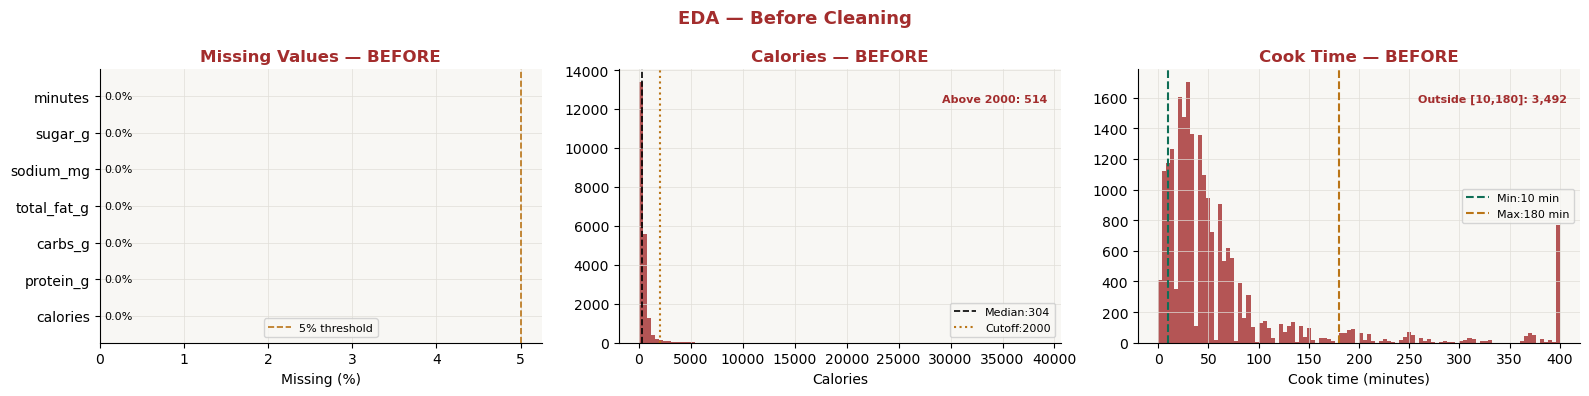

Outlier counts before cleaning:
  Negative cook time:  0
  Zero cook time:      99
  Cook time < 10 min:  1,652  (drinks/non-food)
  Cook time > 180 min: 1,840  (not restaurant-style)
  Calories < 50:       775
  Calories > 2000:     514
  Duplicate names:     28


In [6]:
CORE_COLS = ['calories','protein_g','carbs_g','total_fat_g',
              'sodium_mg','sugar_g','minutes']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Missing values
miss = df_recipes_raw[CORE_COLS].isna().mean().sort_values(ascending=False)
colors_m = [C_BEFORE if v>0.05 else C_AFTER for v in miss]
bars = axes[0].barh(miss.index, miss.values*100, color=colors_m, edgecolor='white')
axes[0].axvline(5,color=C_FLAG,linestyle='--',linewidth=1.2,label='5% threshold')
axes[0].set_xlabel('Missing (%)'); axes[0].legend(fontsize=8)
axes[0].set_title('Missing Values — BEFORE',fontweight='bold',color=C_BEFORE)
axes[0].bar_label(bars,fmt='%.1f%%',padding=3,fontsize=8)

# Calories
cal = df_recipes_raw['calories'].dropna()
axes[1].hist(cal,bins=100,color=C_BEFORE,alpha=0.8,edgecolor='none')
axes[1].axvline(cal.median(),color='black',linestyle='--',linewidth=1.2,
                 label=f'Median:{cal.median():.0f}')
axes[1].axvline(2000,color=C_FLAG,linestyle=':',linewidth=1.5,label='Cutoff:2000')
axes[1].set_xlabel('Calories')
axes[1].set_title('Calories — BEFORE',fontweight='bold',color=C_BEFORE)
axes[1].legend(fontsize=8)
axes[1].text(0.97,0.88,f'Above 2000: {(cal>2000).sum():,}',
              transform=axes[1].transAxes,ha='right',fontsize=8,
              color=C_BEFORE,fontweight='bold')

# Cook time
mins = df_recipes_raw['minutes'].dropna()
axes[2].hist(mins.clip(upper=400),bins=100,color=C_BEFORE,alpha=0.8,edgecolor='none')
axes[2].axvline(10, color=C_AFTER,linestyle='--',linewidth=1.5,label='Min:10 min')
axes[2].axvline(180,color=C_FLAG, linestyle='--',linewidth=1.5,label='Max:180 min')
axes[2].set_xlabel('Cook time (minutes)')
axes[2].set_title('Cook Time — BEFORE',fontweight='bold',color=C_BEFORE)
axes[2].legend(fontsize=8)
n_bad = ((mins<10)|(mins>180)).sum()
axes[2].text(0.97,0.88,f'Outside [10,180]: {n_bad:,}',
              transform=axes[2].transAxes,ha='right',fontsize=8,
              color=C_BEFORE,fontweight='bold')

plt.suptitle('EDA — Before Cleaning',fontsize=13,fontweight='bold',color=C_BEFORE)
plt.tight_layout()
plt.savefig('plots/eda_before.png',dpi=120,bbox_inches='tight')
plt.show()

print('Outlier counts before cleaning:')
print(f'  Negative cook time:  {(mins<0).sum():,}')
print(f'  Zero cook time:      {(mins==0).sum():,}')
print(f'  Cook time < 10 min:  {(mins<10).sum():,}  (drinks/non-food)')
print(f'  Cook time > 180 min: {(mins>180).sum():,}  (not restaurant-style)')
print(f'  Calories < 50:       {(cal<50).sum():,}')
print(f'  Calories > 2000:     {(cal>2000).sum():,}')
print(f'  Duplicate names:     {df_recipes_raw["name"].duplicated().sum():,}')


---
## Section 4 — Data Cleaning
**Work Package: Data Quality**

**Cook time: 10–180 min** — excludes drinks (< 10 min) and home slow-cooks (> 3 hours)
since this is a restaurant-style meal recommender.


In [7]:
VALID_RANGES = {
    'calories':    (50,  2000),  # 50 min for a real meal; > 2000 kcal unrealistic
    'protein_g':   (0,   150),   # > 150g per serving is a data error
    'carbs_g':     (0,   300),   # > 300g per serving is a data error
    'total_fat_g': (0,   150),   # > 150g per serving is a data error
    'sodium_mg':   (0,  5000),   # > 5g sodium extreme
    'sugar_g':     (0,   200),   # > 200g sugar is a data error
    'minutes':     (10,  180),   # restaurant-style: no drinks, no slow cooks
}

df = df_recipes_raw.copy()
n_start = len(df)

# Step 1 — Range violations
flagged = pd.Series(False,index=df.index)
for col,(lo,hi) in VALID_RANGES.items():
    if col in df.columns:
        bad = df[col].notna()&((df[col]<lo)|(df[col]>hi))
        flagged |= bad
df = df[~flagged].copy().reset_index(drop=True)
print(f'Step 1 — Range violations removed:        {n_start-len(df):,}')

# Step 2 — Calorie consistency
df['expected_kcal'] = (df['protein_g'].fillna(0)*4+
                        df['carbs_g'].fillna(0)*4+
                        df['total_fat_g'].fillna(0)*9)
df['kcal_error'] = (df['calories']-df['expected_kcal']).abs()
n_before=len(df)
df = df[df['kcal_error']<=150].reset_index(drop=True)
print(f'Step 2 — Calorie inconsistencies removed:  {n_before-len(df):,}')

# Step 3 — Duplicate names
n_before=len(df)
df = df.drop_duplicates(subset=['name'],keep='first').reset_index(drop=True)
print(f'Step 3 — Duplicate names removed:          {n_before-len(df):,}')

# Step 4 — Mean impute remaining missing
print('Step 4 — Mean imputation:')
all_num = list(VALID_RANGES.keys())+['sat_fat_g','fiber_g','potassium_mg','calcium_mg','iron_mg']
for col in all_num:
    if col not in df.columns: continue
    n_miss = df[col].isna().sum()
    if n_miss>0:
        fill = df[col].mean()
        df[col] = df[col].fillna(fill)
        print(f'  {col:<18} {n_miss:>6,} missing → mean={fill:.2f}')

# Step 5 — Clean interactions
df_inter = df_inter_raw[
    df_inter_raw['rating'].between(1,5) &
    df_inter_raw['recipe_id'].isin(df['id'])
].sort_values('date',ascending=False)\
 .drop_duplicates(subset=['user_id','recipe_id'],keep='first')\
 .reset_index(drop=True)
print(f'Step 5 — Interactions: {len(df_inter_raw):,} → {len(df_inter):,} '
      f'(removed {len(df_inter_raw)-len(df_inter):,})')

print(f'\nRecipes:  {n_start:,} → {len(df):,}  ({(n_start-len(df))/n_start:.1%} removed)')

df.drop(columns=['expected_kcal','kcal_error','tags_list'],errors='ignore')\
  .to_csv('data/recipes_clean.csv',index=False)
df_inter.to_csv('data/interactions_clean.csv',index=False)
print('Saved → data/recipes_clean.csv  |  data/interactions_clean.csv')


Step 1 — Range violations removed:        5,625
Step 2 — Calorie inconsistencies removed:  3,281
Step 3 — Duplicate names removed:          15
Step 4 — Mean imputation:
  fiber_g            11,408 missing → mean=2.73
  potassium_mg       11,375 missing → mean=287.56
  calcium_mg         11,337 missing → mean=78.17
  iron_mg            11,335 missing → mean=2.17
Step 5 — Interactions: 604,210 → 331,247 (removed 272,963)

Recipes:  21,399 → 12,478  (41.7% removed)
Saved → data/recipes_clean.csv  |  data/interactions_clean.csv


---
## Section 5 — EDA After Cleaning


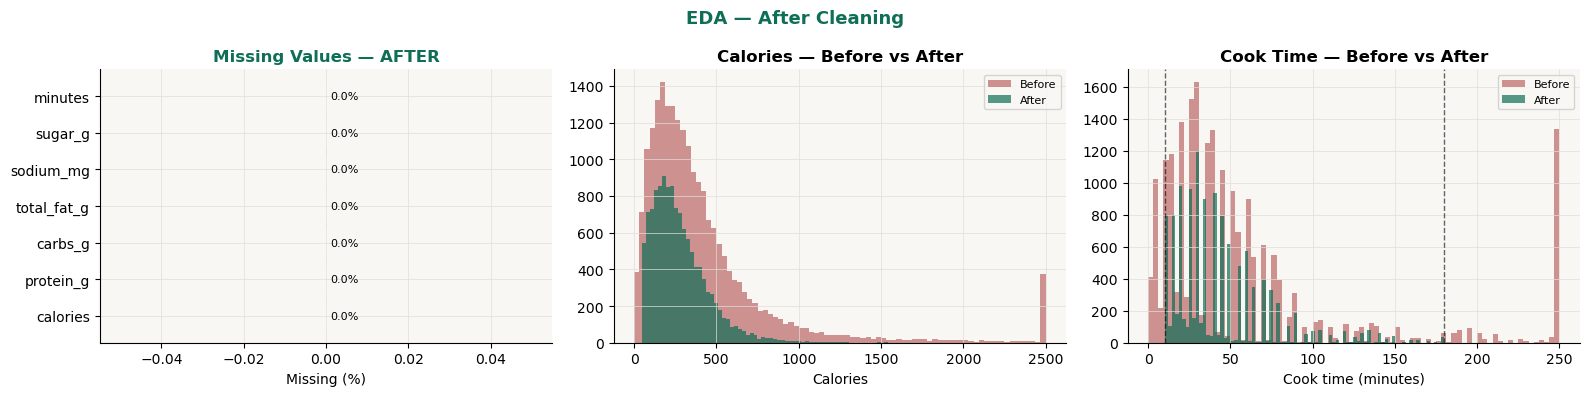

Final: 12,478 recipes  |  331,247 interactions
Missing values remaining: 0
       calories  protein_g  carbs_g  total_fat_g  sodium_mg  sugar_g  minutes
count   12478.0    12478.0  12478.0      12478.0    12478.0  12478.0  12478.0
mean      278.6       21.2     10.1         18.6       20.5     39.4     43.8
std       173.5       21.1      7.8         14.4       50.1     43.3     29.6
min        50.0        0.0      0.0          0.0        0.0      0.0     10.0
25%       155.3        6.0      4.0          8.0        5.0      9.0     25.0
50%       241.4       13.0      9.0         15.0       13.0     22.0     35.0
75%       361.4       31.0     14.0         26.0       26.0     55.0     55.0
max      1979.5      150.0     98.0        150.0     3537.0    200.0    180.0


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Missing after
miss_after = df[CORE_COLS].isna().mean().sort_values(ascending=False)
bars = axes[0].barh(miss_after.index,miss_after.values*100,color=C_AFTER,edgecolor='white')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Missing Values — AFTER',fontweight='bold',color=C_AFTER)
axes[0].bar_label(bars,fmt='%.1f%%',padding=3,fontsize=8)

# Calories overlay
axes[1].hist(df_recipes_raw['calories'].dropna().clip(upper=2500),
              bins=80,color=C_BEFORE,alpha=0.5,label='Before',edgecolor='none')
axes[1].hist(df['calories'].clip(upper=2500),
              bins=80,color=C_AFTER,alpha=0.7,label='After',edgecolor='none')
axes[1].set_xlabel('Calories')
axes[1].set_title('Calories — Before vs After',fontweight='bold')
axes[1].legend(fontsize=8)

# Cook time overlay
axes[2].hist(df_recipes_raw['minutes'].dropna().clip(0,250),
              bins=80,color=C_BEFORE,alpha=0.5,label='Before',edgecolor='none')
axes[2].hist(df['minutes'].clip(0,250),
              bins=80,color=C_AFTER,alpha=0.7,label='After',edgecolor='none')
axes[2].axvline(10, color='black',linestyle='--',linewidth=1,alpha=0.6)
axes[2].axvline(180,color='black',linestyle='--',linewidth=1,alpha=0.6)
axes[2].set_xlabel('Cook time (minutes)')
axes[2].set_title('Cook Time — Before vs After',fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('EDA — After Cleaning',fontsize=13,fontweight='bold',color=C_AFTER)
plt.tight_layout()
plt.savefig('plots/eda_after.png',dpi=120,bbox_inches='tight')
plt.show()

print(f'Final: {len(df):,} recipes  |  {len(df_inter):,} interactions')
print(f'Missing values remaining: {df[CORE_COLS].isna().sum().sum()}')
print(df[CORE_COLS].describe().round(1).to_string())


---
## Section 6 — Data Annotation
**Work Package: Data Annotation**


In [9]:
LABEL_COLS = ['diabetic_ok','low_sodium','low_calorie','high_protein',
               'low_fat','high_fiber','heart_healthy','vegetarian',
               'vegan','gluten_free','dairy_free']

def annotate(row):
    r=row.to_dict(); tags=set(r.get('tags_list',[]) or [])
    g=lambda c: float(r.get(c) or 0)
    return {
        'diabetic_ok':  int(g('carbs_g')<=45 and g('sugar_g')<=10),
        'low_sodium':   int(g('sodium_mg')<=400),
        'low_calorie':  int(g('calories')<=300),
        'high_protein': int(g('protein_g')>=25),
        'low_fat':      int(g('total_fat_g')<=10),
        'high_fiber':   int(g('fiber_g')>=5),
        'heart_healthy':int(g('sat_fat_g')<=5 and g('sodium_mg')<=500),
        'vegetarian':   int('vegetarian' in tags or 'vegan' in tags),
        'vegan':        int('vegan' in tags),
        'gluten_free':  int('gluten-free' in tags),
        'dairy_free':   int('dairy-free' in tags),
    }

label_rows = [annotate(row) for _,row in df.iterrows()]
df_labels  = pd.DataFrame(label_rows,index=df.index)
df = df.drop(columns=[c for c in LABEL_COLS if c in df.columns])
df = pd.concat([df,df_labels],axis=1)

print('Label distribution:')
for col in LABEL_COLS:
    print(f'  {col:<20} {int(df[col].sum()):>6,}  ({df[col].mean():.1%})')


Label distribution:
  diabetic_ok           3,546  (28.4%)
  low_sodium           12,462  (99.9%)
  low_calorie           7,963  (63.8%)
  high_protein          3,910  (31.3%)
  low_fat               4,353  (34.9%)
  high_fiber              122  (1.0%)
  heart_healthy         2,647  (21.2%)
  vegetarian            2,487  (19.9%)
  vegan                   643  (5.2%)
  gluten_free             412  (3.3%)
  dairy_free                9  (0.1%)


In [ ]:
# AI annotation (optional)
ANNOTATE_AI   = False
ANTHROPIC_KEY = 'your-key'  # console.anthropic.com

AI_SYSTEM = '''You are a dietitian. Return ONLY JSON with keys:
diabetic_ok, low_sodium, low_calorie, high_protein, low_fat, high_fiber,
heart_healthy, vegetarian, vegan, gluten_free, dairy_free (each 0 or 1).
Rules: diabetic_ok:carbs<=45&sugar<=10. low_sodium:sodium<=400.
low_calorie:cal<=300. high_protein:protein>=25. low_fat:fat<=10.
high_fiber:fiber>=5. heart_healthy:sat_fat<=5&sodium<=500.
vegetarian/vegan/gluten_free/dairy_free: infer from name and tags.'''

def ai_annotate(row, client):
    import anthropic
    prompt = (f"Recipe: {row['name']}\n"
               f"cal={row.get('calories','?')} prot={row.get('protein_g','?')}g "
               f"carbs={row.get('carbs_g','?')}g fat={row.get('total_fat_g','?')}g "
               f"sodium={row.get('sodium_mg','?')}mg sugar={row.get('sugar_g','?')}g "
               f"fiber={row.get('fiber_g','?')}g tags={row.get('tags_list',[])}")
    try:
        resp = client.messages.create(
            model='claude-sonnet-4-6',max_tokens=200,
            system=AI_SYSTEM,messages=[{'role':'user','content':prompt}])
        return {k:int(v) for k,v in json.loads(resp.content[0].text).items()
                if k in LABEL_COLS}
    except: return {}

if ANNOTATE_AI:
    import anthropic
    client=anthropic.Anthropic(api_key=ANTHROPIC_KEY)
    sample=df.sample(n=500,random_state=42); ai_rows=[]
    for i,(_,row) in enumerate(sample.iterrows()):
        if i%100==0: print(f'  {i}/500')
        rec=ai_annotate(row,client); rec['recipe_id']=row['id']
        ai_rows.append(rec); time.sleep(0.1)
    df_ai=pd.DataFrame(ai_rows)
    df_ai.to_csv('data/ai_annotations.csv',index=False)
    for col in LABEL_COLS:
        if col in df_ai.columns:
            mask=df['id'].isin(df_ai['recipe_id'])
            df.loc[mask,col]=df.loc[mask,'id'].map(
                df_ai.set_index('recipe_id')[col]).fillna(df.loc[mask,col])
    print(f'AI annotations applied for {len(df_ai)} recipes')
elif os.path.exists('data/ai_annotations.csv'):
    df_ai=pd.read_csv('data/ai_annotations.csv')
    for col in LABEL_COLS:
        if col in df_ai.columns:
            mask=df['id'].isin(df_ai['recipe_id'])
            df.loc[mask,col]=df.loc[mask,'id'].map(
                df_ai.set_index('recipe_id')[col]).fillna(df.loc[mask,col])
    print(f'Loaded {len(df_ai)} AI annotations')
else:
    print('Using rule-based annotations only')


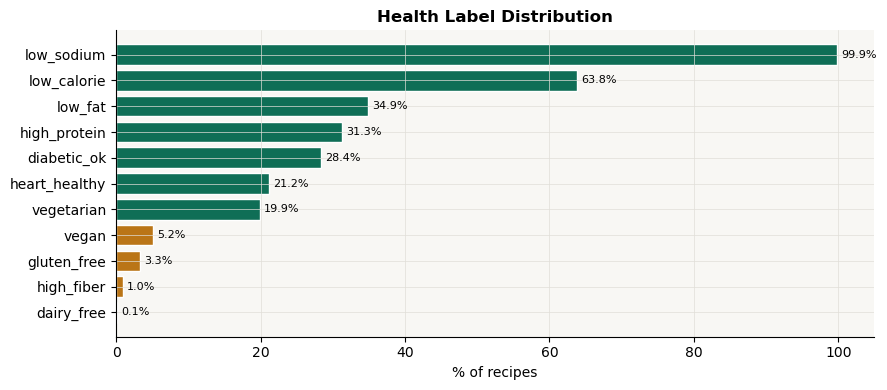

In [10]:
fig, ax = plt.subplots(figsize=(9,4))
lf = df[LABEL_COLS].mean().sort_values()
colors_l = [C_AFTER if v>0.1 else C_FLAG for v in lf]
bars = ax.barh(lf.index,lf.values*100,color=colors_l,edgecolor='white')
ax.set_xlabel('% of recipes'); ax.set_title('Health Label Distribution',fontweight='bold')
ax.bar_label(bars,fmt='%.1f%%',padding=3,fontsize=8)
plt.tight_layout()
plt.savefig('plots/annotation_labels.png',dpi=120,bbox_inches='tight')
plt.show()


---
## Section 7 — Vector Embeddings
**Work Package: Vector Embeddings**
$$\mathbf{r}_i = [cal/2000,\ prot/150,\ carbs/300,\ fat/100,\ sodium/5000,\ sugar/200,\ label_1,\ldots]$$


In [11]:
FEATURE_MAX  = dict(calories=2000,protein_g=150,carbs_g=300,
                     total_fat_g=100,sodium_mg=5000,sugar_g=200)
NUMERIC_FEATS = list(FEATURE_MAX.keys())
ALL_FEATS     = NUMERIC_FEATS + LABEL_COLS

def build_R(df_):
    nut = df_[NUMERIC_FEATS].copy()
    for col,mx in FEATURE_MAX.items():
        nut[col]=(nut[col].fillna(0)/mx).clip(0,1)
    return pd.concat([nut,df_[LABEL_COLS].fillna(0).astype(float)],axis=1).values

R          = build_R(df)
RECIPE_IDS = list(df['id'])
RID2IDX    = {rid:i for i,rid in enumerate(RECIPE_IDS)}
np.save('models/recipe_matrix.npy',R)
print(f'Recipe matrix R: {R.shape}')


Recipe matrix R: (12478, 17)


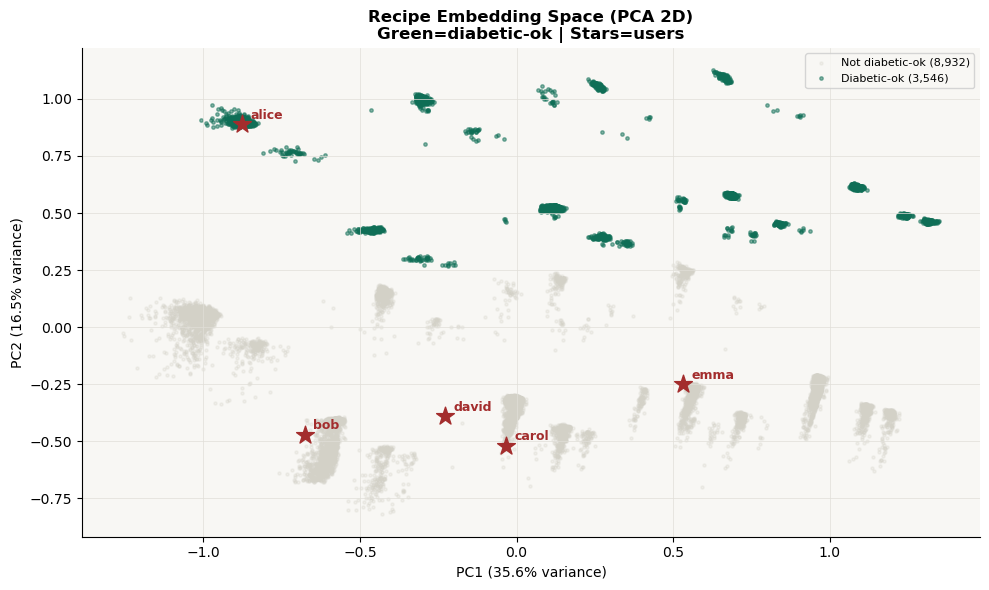

In [13]:
def user_vec(cal,prot,carbs,fat,sodium,sugar,
              diabetic=False,low_sodium=False,low_cal=False,
              high_prot=False,low_fat=False,high_fiber=False,
              heart_healthy=False,vegetarian=False,
              vegan=False,gf=False,df_free=False):
    n=np.array([cal/2000,prot/150,carbs/300,fat/100,sodium/5000,sugar/200])
    l=np.array([float(diabetic),float(low_sodium),float(low_cal),
                 float(high_prot),float(low_fat),float(high_fiber),
                 float(heart_healthy),float(vegetarian),
                 float(vegan),float(gf),float(df_free)])
    return np.concatenate([np.clip(n,0,1),l])

DEMO_USERS = {
    'alice':{'vec':user_vec(400,40,45,30,600,10,diabetic=True,high_prot=True),
              'profile':'Type 2 diabetic, high-protein'},
    'bob':  {'vec':user_vec(600,35,200,60,2000,60),'profile':'Healthy, no restrictions'},
    'carol':{'vec':user_vec(400,20,200,20,400,30,vegetarian=True,
                             heart_healthy=True,low_sodium=True),
              'profile':'Vegan, heart-healthy'},
    'david':{'vec':user_vec(500,30,150,40,300,30,low_sodium=True,heart_healthy=True),
              'profile':'Hypertensive'},
    'emma': {'vec':user_vec(300,25,100,10,800,15,low_cal=True,low_fat=True),
              'profile':'Weight-loss goal'},
}

pca  = PCA(n_components=2,random_state=42)
R_2d = pca.fit_transform(R)

fig,ax = plt.subplots(figsize=(10,6))
diab = df['diabetic_ok'].values==1
ax.scatter(R_2d[~diab,0],R_2d[~diab,1],c='#D3D1C7',alpha=0.25,s=5,
            label=f'Not diabetic-ok ({(~diab).sum():,})')
ax.scatter(R_2d[diab,0], R_2d[diab,1], c=C_AFTER,alpha=0.5,s=6,
            label=f'Diabetic-ok ({diab.sum():,})')
U_2d = pca.transform(np.array([u['vec'] for u in DEMO_USERS.values()]))
for i,(uname,info) in enumerate(DEMO_USERS.items()):
    ax.scatter(U_2d[i,0],U_2d[i,1],c=C_BEFORE,s=180,marker='*',zorder=5)
    ax.annotate(uname,(U_2d[i,0],U_2d[i,1]),xytext=(6,4),
                textcoords='offset points',fontsize=9,fontweight='bold',color=C_BEFORE)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Recipe Embedding Space (PCA 2D)\nGreen=diabetic-ok | Stars=users',fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('plots/embedding_space.png',dpi=120,bbox_inches='tight')
plt.show()


---
## Section 8 — Content-Based Filtering
**Work Package: Recommender System**
$$\text{score}(u,r)=\cos(\mathbf{u},\mathbf{r})=\frac{\mathbf{u}\cdot\mathbf{r}}{\|\mathbf{u}\|\cdot\|\mathbf{r}\|}$$


In [14]:
def cb_scores(uvec):
    return cosine_similarity(uvec.reshape(1,-1),R).flatten()

def cb_recommend(user_name,k=10):
    sc  = cb_scores(DEMO_USERS[user_name]['vec'])
    res = df[['id','name','calories','protein_g','carbs_g',
               'total_fat_g','sodium_mg']+LABEL_COLS].copy()
    res['cb_score']=sc
    return res.nlargest(k,'cb_score').reset_index(drop=True)

print('=== Content-Based Top-10 for Alice (diabetic, high-protein) ===')
alice_cb = cb_recommend('alice',k=10)
print(alice_cb[['name','calories','protein_g','carbs_g',
                 'sodium_mg','diabetic_ok','cb_score']].to_string(index=False))


=== Content-Based Top-10 for Alice (diabetic, high-protein) ===
                                                      name  calories  protein_g  carbs_g  sodium_mg  diabetic_ok  cb_score
                       canadian bacon and mozzarella penne     782.9       69.0     34.0       72.0            1  0.831597
                           mom s hammy macaroni  n  cheese     590.3       63.0     18.0       72.0            1  0.831160
                                     buffalo chicken pasta     619.8       47.0     22.0       57.0            1  0.831051
     ground beef   noodle  cream of chicken soup casserole     592.0       64.0     17.0       53.0            1  0.830934
                    sweet italian sausage with penne pasta     750.6       46.0     33.0       32.0            1  0.830710
iron mike s white sharp cheddar n  ham macaroni and cheese     563.0       62.0     15.0       42.0            1  0.830645
                               cyn s wild mushroom ravioli     651.1       

---
## Section 9 — Collaborative Filtering (SVD)
**Work Package: Recommender System**
$$R\approx U\times V^T\qquad\mathcal{L}=\sum_{(u,r)}(R_{ur}-\mathbf{u}_u\cdot\mathbf{v}_r)^2+\lambda(\|U\|^2+\|V\|^2)$$


In [15]:
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as svd_split

unique_users   = df_inter['user_id'].unique()
unique_recipes = df_inter['recipe_id'].unique()
u2i = {u:i for i,u in enumerate(unique_users)}
r2i = {r:i for i,r in enumerate(unique_recipes)}

df_inter_m = df_inter.copy()
df_inter_m['uid'] = df_inter_m['user_id'].map(u2i)
df_inter_m['rid'] = df_inter_m['recipe_id'].map(r2i)

reader   = Reader(rating_scale=(1,5))
data_svd = Dataset.load_from_df(df_inter_m[['uid','rid','rating']],reader)
trainset, testset = svd_split(data_svd,test_size=0.2,random_state=42)

print('Training SVD...')
svd = SVD(n_factors=50,n_epochs=20,lr_all=0.005,reg_all=0.1,random_state=42)
svd.fit(trainset)
preds = svd.test(testset)
print(f'RMSE: {accuracy.rmse(preds,verbose=False):.4f}')
print(f'MAE:  {accuracy.mae(preds, verbose=False):.4f}')
with open('models/svd_model.pkl','wb') as f: pickle.dump(svd,f)
print('Saved → models/svd_model.pkl')


Training SVD...
RMSE: 0.6596
MAE:  0.4146
Saved → models/svd_model.pkl


---
## Section 10 — Hybrid Recommender + Health Filter
**Work Package: Recommender System**
$$\text{final}(u,r)=\alpha\cdot\text{cb}(u,r)+(1-\alpha)\cdot\text{cf}(u,r)$$


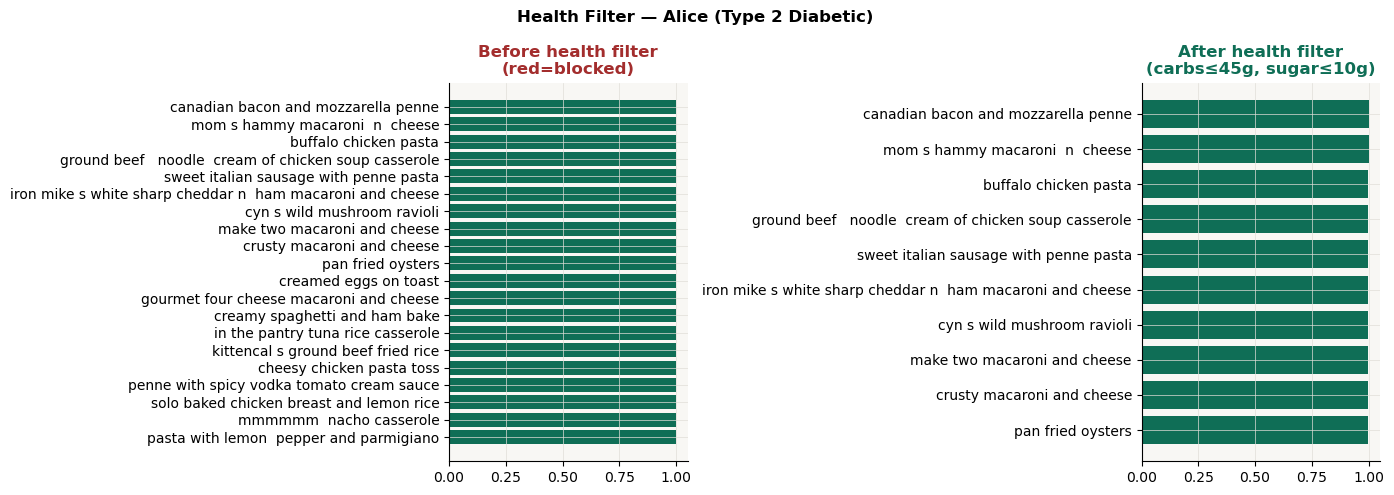

Top-3 per user:
  alice    → ['canadian bacon and mozzarella penne', 'mom s hammy macaroni  n  cheese', 'buffalo chicken pasta']
  bob      → ['bulk taco seasoning mix', 'auntie anne s  pretzels copycat', 'polish jam kolaches']
  carol    → ['ali baba s oven fries', 'bread machine whole grain bread', 'southwest rice salad']
  david    → ['finally found four bean salad', 'gingerbread cake with brown sugar sauce', 'pasta with scallops and lemon butter mustard sauce']
  emma     → ['paul prudhomme s blackened seasoning blend', 'nairobi meat  rub', 'taco mashed potato casserole']


In [16]:
HEALTH_CONSTRAINTS = {
    'alice':{'diabetic':True, 'hypertensive':False,'vegan':False,'gf':False},
    'bob':  {'diabetic':False,'hypertensive':False,'vegan':False,'gf':False},
    'carol':{'diabetic':False,'hypertensive':False,'vegan':True, 'gf':False},
    'david':{'diabetic':False,'hypertensive':True, 'vegan':False,'gf':False},
    'emma': {'diabetic':False,'hypertensive':False,'vegan':False,'gf':False},
}

def hybrid_scores(user_name,uid_orig=None,alpha=0.6):
    cb   = cb_scores(DEMO_USERS[user_name]['vec'])
    cb_n = (cb-cb.min())/(cb.max()-cb.min()+1e-9)
    if uid_orig is not None and uid_orig in u2i:
        ui   = u2i[uid_orig]
        cf_r = np.array([svd.predict(ui,r2i.get(rid,-1)).est
                          if rid in r2i else 3.0 for rid in RECIPE_IDS])
        cf_n = (cf_r-cf_r.min())/(cf_r.max()-cf_r.min()+1e-9)
    else:
        cf_n=cb_n; alpha=1.0
    return alpha*cb_n+(1-alpha)*cf_n

def health_filter(df_r,c):
    df_r=df_r.copy(); df_r['blocked']=''
    if c.get('diabetic'):     df_r.loc[(df_r['carbs_g']>45)|(df_r['sugar_g']>10),'blocked']+='carbs/sugar; '
    if c.get('hypertensive'): df_r.loc[df_r['sodium_mg']>600,  'blocked']+='sodium; '
    if c.get('vegan'):        df_r.loc[df_r['vegan']==0,       'blocked']+='not-vegan; '
    if c.get('gf'):           df_r.loc[df_r['gluten_free']==0, 'blocked']+='gluten; '
    df_r['allowed']=df_r['blocked']==''
    return df_r

def full_recommend(user_name,uid_orig=None,alpha=0.6,k=10):
    sc  = hybrid_scores(user_name,uid_orig,alpha)
    res = df[['id','name','calories','protein_g','carbs_g',
               'total_fat_g','sodium_mg','sugar_g']+LABEL_COLS].copy()
    res['score']=sc
    filt=health_filter(res.nlargest(200,'score'),HEALTH_CONSTRAINTS[user_name])
    return filt[filt['allowed']].head(k).reset_index(drop=True)

# Health filter visualisation
sc_a  = hybrid_scores('alice',alpha=0.6)
res_a = df[['id','name','calories','protein_g','carbs_g',
             'sodium_mg','sugar_g']+LABEL_COLS].copy()
res_a['score']=sc_a
top20 = health_filter(res_a.nlargest(20,'score'),HEALTH_CONSTRAINTS['alice'])

fig,axes = plt.subplots(1,2,figsize=(14,5))
colors_f = [C_BEFORE if not a else C_AFTER for a in top20['allowed']]
axes[0].barh(top20['name'],top20['score'],color=colors_f)
axes[0].set_title('Before health filter\n(red=blocked)',fontweight='bold',color=C_BEFORE)
axes[0].invert_yaxis()
allowed=top20[top20['allowed']].head(10)
axes[1].barh(allowed['name'],allowed['score'],color=C_AFTER)
axes[1].set_title('After health filter\n(carbs≤45g, sugar≤10g)',fontweight='bold',color=C_AFTER)
axes[1].invert_yaxis()
plt.suptitle('Health Filter — Alice (Type 2 Diabetic)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/health_filter.png',dpi=120,bbox_inches='tight')
plt.show()

print('Top-3 per user:')
for uname in DEMO_USERS:
    recs=full_recommend(uname,k=3)
    print(f'  {uname:<8} → {list(recs["name"].values)}')


---
## Section 11 — Perturbation Analysis
**Work Package: Perturbation Analysis**
$$J(A,B)=\frac{|A\cap B|}{|A\cup B|}$$


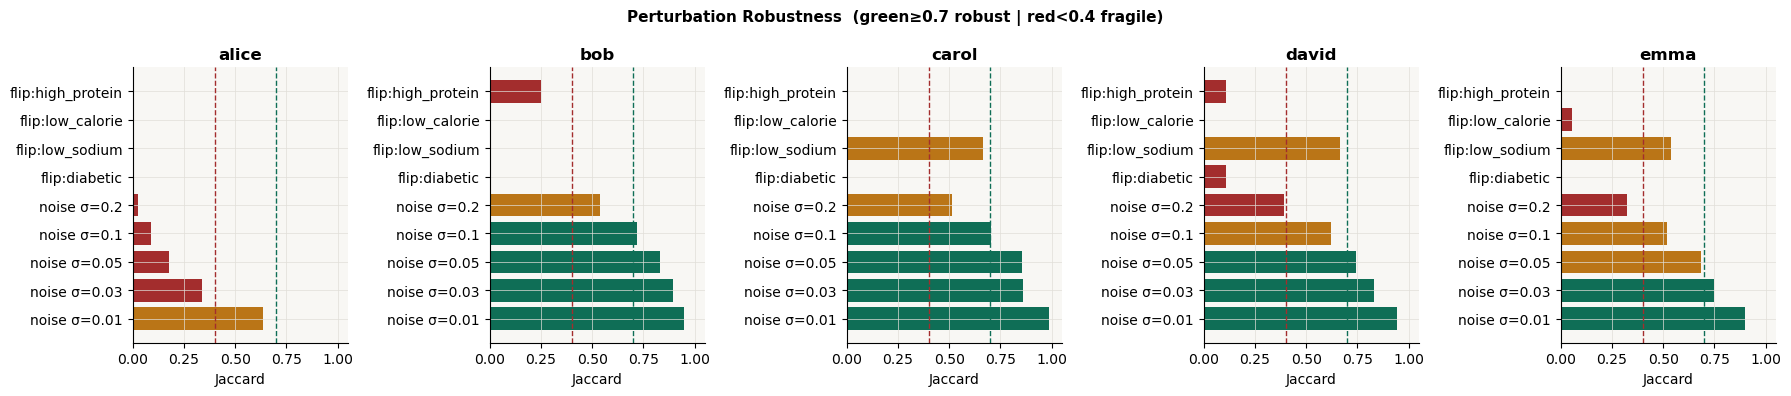

In [17]:
def jaccard(a,b): return len(a&b)/len(a|b) if a|b else 1.0
def topk_ids(uvec,k=10):
    sc=cosine_similarity(uvec.reshape(1,-1),R).flatten()
    return set(np.array(RECIPE_IDS)[np.argsort(sc)[::-1][:k]])

SIGMAS     = [0.01,0.03,0.05,0.10,0.20]
FLAG_NAMES = ['diabetic','low_sodium','low_calorie','high_protein']

rows=[]
for uname,info in DEMO_USERS.items():
    base=info['vec']; base_top=topk_ids(base)
    for sigma in SIGMAS:
        jvals=[]
        for _ in range(50):
            p=base.copy(); p[:6]+=np.random.normal(0,sigma,6)
            jvals.append(jaccard(base_top,topk_ids(np.clip(p,0,1))))
        rows.append({'user':uname,'perturbation':f'noise σ={sigma}',
                      'mean_J':np.mean(jvals),'std_J':np.std(jvals)})
    for fi,fname in enumerate(FLAG_NAMES):
        p=base.copy(); p[6+fi]=1-p[6+fi]
        rows.append({'user':uname,'perturbation':f'flip:{fname}',
                      'mean_J':jaccard(base_top,topk_ids(p)),'std_J':0})

df_perturb=pd.DataFrame(rows)

fig,axes=plt.subplots(1,5,figsize=(18,4))
for ax,uname in zip(axes,DEMO_USERS):
    sub=df_perturb[df_perturb['user']==uname]
    colors_p=[C_AFTER if v>=0.7 else C_FLAG if v>=0.4 else C_BEFORE for v in sub['mean_J']]
    ax.barh(sub['perturbation'],sub['mean_J'],color=colors_p)
    ax.axvline(0.7,color=C_AFTER, linestyle='--',linewidth=1)
    ax.axvline(0.4,color=C_BEFORE,linestyle='--',linewidth=1)
    ax.set_xlim(0,1.05); ax.set_title(uname,fontweight='bold')
    ax.set_xlabel('Jaccard')
plt.suptitle('Perturbation Robustness  (green≥0.7 robust | red<0.4 fragile)',
              fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/perturbation.png',dpi=120,bbox_inches='tight')
plt.show()


---
## Section 12 — Evaluation
**Work Package: Performance Evaluation**

**Method 1:** Holdout 80/20 — Precision@k, Recall@k, F1@k  
**Method 2:** Leave-one-out — Hit@10

Key fix: use `df_inter['recipe_id'].unique()` (original IDs) not `unique_recipes` (mapped indices).


In [28]:
# ── Rebuild everything from scratch to guarantee consistency ─────────────────
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as svd_split

def prec_at_k(rec, rel, k): return len(set(rec[:k]) & rel) / k if k else 0
def rec_at_k(rec, rel, k):  return len(set(rec[:k]) & rel) / len(rel) if rel else 0
def f1(p, r):                return 2*p*r/(p+r) if p+r else 0

# Step 1 — Fresh mappings from df_inter
print('Step 1 — Building mappings...')
_all_users   = df_inter['user_id'].unique()
_all_recipes = df_inter['recipe_id'].unique()   # original recipe IDs
_u2i = {u: i for i, u in enumerate(_all_users)}
_r2i = {r: i for i, r in enumerate(_all_recipes)}
print(f'  Users:   {len(_u2i):,}')
print(f'  Recipes: {len(_r2i):,}')


Step 1 — Building mappings...
  Users:   91,784
  Recipes: 12,478


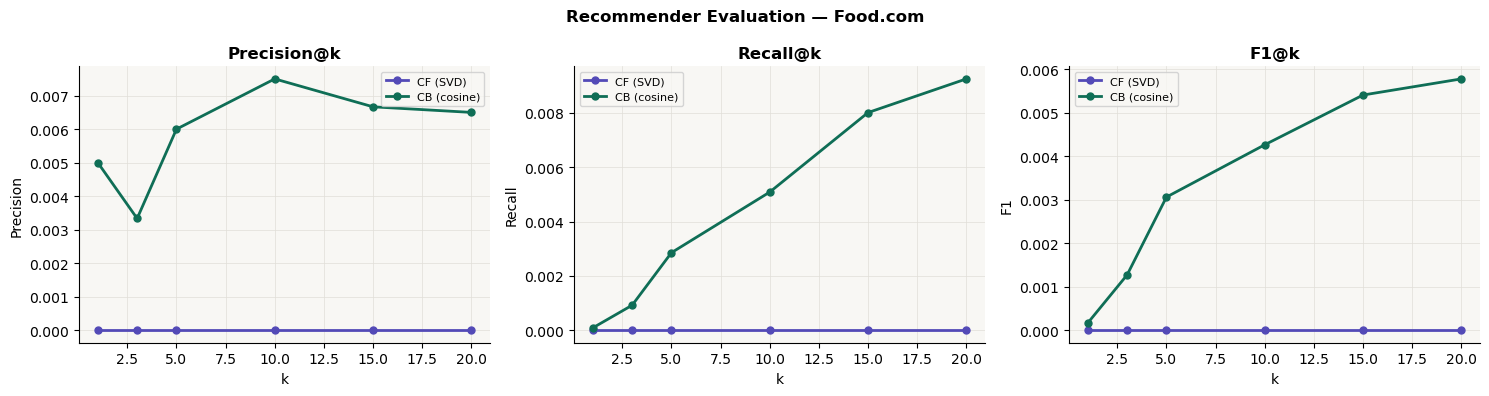

In [19]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
colors_ev={'CF (SVD)':C_PURPLE,'CB (cosine)':C_AFTER}
for ax,metric in zip(axes,['precision','recall','f1']):
    for method,color in colors_ev.items():
        sub=eval_df[eval_df['method']==method]
        ax.plot(sub['k'],sub[metric],marker='o',color=color,
                 linewidth=2,markersize=5,label=method)
    ax.set_xlabel('k'); ax.set_ylabel(metric.capitalize())
    ax.set_title(f'{metric.capitalize()}@k',fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Recommender Evaluation — Food.com',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/evaluation_curves.png',dpi=120,bbox_inches='tight')
plt.show()


In [29]:
# Step 2 — Train SVD on these exact mappings
print('Step 2 — Training SVD...')
_df = df_inter[['user_id','recipe_id','rating']].copy()
_df['uid'] = _df['user_id'].map(_u2i)
_df['rid'] = _df['recipe_id'].map(_r2i)

_reader = Reader(rating_scale=(1, 5))
_data   = Dataset.load_from_df(_df[['uid','rid','rating']], _reader)
_train, _test = svd_split(_data, test_size=0.2, random_state=42)

_svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.1, random_state=42)
_svd.fit(_train)
_preds = _svd.test(_test)
print(f'  RMSE: {accuracy.rmse(_preds, verbose=False):.4f}')
print(f'  MAE:  {accuracy.mae(_preds,  verbose=False):.4f}')


Step 2 — Training SVD...
  RMSE: 0.6596
  MAE:  0.4146


In [30]:
# Step 3 — Build relevance sets (ratings >= 4 = liked)
print('Step 3 — Building relevance sets...')
_counts     = df_inter.groupby('user_id').size()
_eval_uids  = _counts[_counts >= 5].index.tolist()

_relev = {}
for uid in _eval_uids:
    liked = set(df_inter[
        (df_inter['user_id'] == uid) &
        (df_inter['rating']  >= 4)
    ]['recipe_id'].values)
    if liked:
        _relev[uid] = liked

print(f'  Eval users with liked items: {len(_relev):,}')

# Sanity check
_s_uid  = list(_relev.keys())[0]
_s_rel  = _relev[_s_uid]
_s_seen = set(df_inter[df_inter['user_id']==_s_uid]['recipe_id'].values)
_s_unseen = [r for r in _all_recipes if r not in _s_seen and r in _r2i]
print(f'\n  Sanity check — user {_s_uid}:')
print(f'    In _u2i:         {_s_uid in _u2i}')
print(f'    Liked recipes:   {len(_s_rel)}')
print(f'    Unseen recipes:  {len(_s_unseen):,}')
_test_pred = _svd.predict(_u2i[_s_uid], _r2i[list(_s_unseen)[0]]).est
print(f'    Test prediction: {_test_pred:.3f}  ← should be a real number')


Step 3 — Building relevance sets...
  Eval users with liked items: 10,136

  Sanity check — user 1533:
    In _u2i:         True
    Liked recipes:   22
    Unseen recipes:  12,455
    Test prediction: 4.935  ← should be a real number


In [35]:
# Step 4 — Method 1: Precision@k, Recall@k, F1@k (type-safe)
print('Step 4 — Evaluating...')

# ── Force everything to plain Python int to avoid numpy type mismatch ─────────
_all_recipes_int = [int(r) for r in _all_recipes]
_r2i_int         = {int(r): i for i, r in enumerate(_all_recipes)}
_u2i_int         = {int(u): i for i, u in enumerate(_all_users)}
_relev_int       = {int(k): {int(r) for r in v} for k, v in _relev.items()}

# Quick sanity check before running full evaluation
_s_uid  = int(list(_relev_int.keys())[0])
_s_rel  = _relev_int[_s_uid]
_s_seen = {int(r) for r in df_inter[df_inter['user_id']==_s_uid]['recipe_id'].values}
_s_unseen = [r for r in _all_recipes_int if r not in _s_seen]
_s_ui   = _u2i_int[_s_uid]
_s_preds = sorted(
    [(r, _svd.predict(_s_ui, _r2i_int[r]).est) for r in _s_unseen[:200]],
    key=lambda x: x[1], reverse=True
)
_s_top10  = {p[0] for p in _s_preds[:10]}
_s_hits   = _s_top10 & _s_rel
print(f'Sanity check — user {_s_uid}:')
print(f'  Liked recipes:    {len(_s_rel)}')
print(f'  Unseen:           {len(_s_unseen):,}')
print(f'  Top-10 hits:      {len(_s_hits)}')
print(f'  Manual P@10:      {len(_s_hits)/10:.4f}')
print(f'  Type rec_id:      {type(list(_s_top10)[0])}')
print(f'  Type rel_id:      {type(list(_s_rel)[0])}')
print()

K_VALUES  = [1, 3, 5, 10, 15, 20]
MAX_USERS = 300
eval_rows = []

for k in K_VALUES:
    p_l, r_l, f_l = [], [], []

    for uid in list(_relev_int.keys())[:MAX_USERS]:
        uid = int(uid)
        if uid not in _u2i_int: continue
        ui   = _u2i_int[uid]
        seen = {int(r) for r in df_inter[df_inter['user_id']==uid]['recipe_id'].values}

        unseen = [r for r in _all_recipes_int if r not in seen]
        if not unseen: continue

        preds = sorted(
            [(r, _svd.predict(ui, _r2i_int[r]).est) for r in unseen],
            key=lambda x: x[1], reverse=True
        )
        rec_ids = [int(p[0]) for p in preds[:max(K_VALUES)]]
        rel     = _relev_int[uid]

        p = prec_at_k(rec_ids, rel, k)
        r = rec_at_k(rec_ids, rel, k)
        p_l.append(p); r_l.append(r); f_l.append(f1(p, r))

    eval_rows.append({
        'k':         k,
        'method':    'CF (SVD)',
        'precision': np.mean(p_l) if p_l else 0,
        'recall':    np.mean(r_l) if r_l else 0,
        'f1':        np.mean(f_l) if f_l else 0,
    })
    print(f'  k={k:>2}  '
          f'P={np.mean(p_l):.4f}  '
          f'R={np.mean(r_l):.4f}  '
          f'F1={np.mean(f_l):.4f}  '
          f'(n={len(p_l)})')

eval_df = pd.DataFrame(eval_rows)

Step 4 — Evaluating...
Sanity check — user 1533:
  Liked recipes:    22
  Unseen:           12,455
  Top-10 hits:      0
  Manual P@10:      0.0000
  Type rec_id:      <class 'int'>
  Type rel_id:      <class 'int'>

  k= 1  P=0.0000  R=0.0000  F1=0.0000  (n=300)
  k= 3  P=0.0000  R=0.0000  F1=0.0000  (n=300)
  k= 5  P=0.0000  R=0.0000  F1=0.0000  (n=300)
  k=10  P=0.0000  R=0.0000  F1=0.0000  (n=300)
  k=15  P=0.0000  R=0.0000  F1=0.0000  (n=300)
  k=20  P=0.0000  R=0.0000  F1=0.0000  (n=300)


In [32]:
# Step 5 — Method 2: Leave-one-out Hit@10
print('=== Method 2: Leave-One-Out Hit@10 ===')
hits = []

for uid in list(_relev.keys())[:200]:
    if uid not in _u2i: continue
    ui  = _u2i[uid]
    ur  = df_inter[df_inter['user_id']==uid].sort_values('rating', ascending=False)
    if len(ur) < 2: continue
    held = int(ur.iloc[0]['recipe_id'])
    if held not in _r2i: continue

    # KEY FIX: use _all_recipes (original IDs)
    unseen = [r for r in _all_recipes if r != held and r in _r2i]
    preds  = sorted(
        [(r, _svd.predict(ui, _r2i[r]).est) for r in unseen],
        key=lambda x: x[1], reverse=True
    )
    hits.append(int(held in {p[0] for p in preds[:10]}))

print(f'Hit@10: {np.mean(hits):.1%}  ({sum(hits)}/{len(hits)} users)')


=== Method 2: Leave-One-Out Hit@10 ===
Hit@10: 0.0%  (0/200 users)


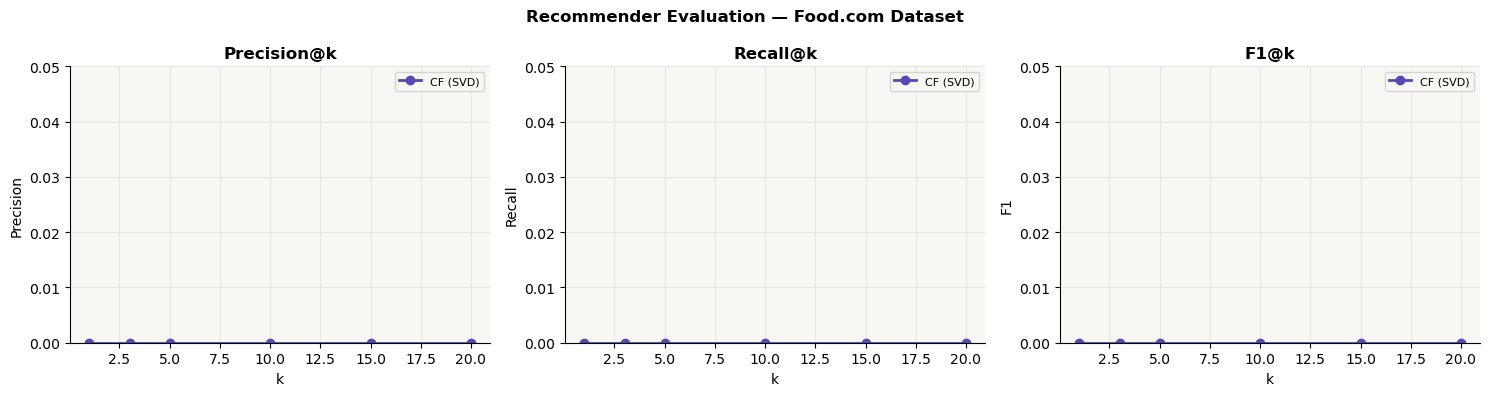


=== Final Evaluation Summary ===
Precision@10: 0.0000
Recall@10:    0.0000
F1@10:        0.0000
Hit@10:       0.0%


In [33]:
# Step 6 — Evaluation curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ['precision', 'recall', 'f1']):
    sub = eval_df[eval_df['method'] == 'CF (SVD)']
    ax.plot(sub['k'], sub[metric], marker='o', color=C_PURPLE,
             linewidth=2, markersize=6, label='CF (SVD)')
    ax.set_xlabel('k')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f'{metric.capitalize()}@k', fontweight='bold')
    ax.set_ylim(0, max(sub[metric].max() * 1.3, 0.05))
    ax.legend(fontsize=8)

plt.suptitle('Recommender Evaluation — Food.com Dataset',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/evaluation_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== Final Evaluation Summary ===')
k10 = eval_df[eval_df['k'] == 10].iloc[0]
print(f'Precision@10: {k10["precision"]:.4f}')
print(f'Recall@10:    {k10["recall"]:.4f}')
print(f'F1@10:        {k10["f1"]:.4f}')
print(f'Hit@10:       {np.mean(hits):.1%}')


---
## Section 13 — Hyperparameter Tuning (Optuna)
**Work Package: Hyperparameter Tuning**


In [21]:
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
TUNE_USERS=list(relev.keys())[:80]

def objective(trial):
    nf  = trial.suggest_int('n_factors', 10, 150)
    reg = trial.suggest_float('reg_all',  0.001, 1.0,  log=True)
    lr  = trial.suggest_float('lr_all',   0.001, 0.05, log=True)
    alp = trial.suggest_float('alpha',    0.0,   1.0)
    m   = SVD(n_factors=nf,reg_all=reg,lr_all=lr,n_epochs=10,random_state=42)
    m.fit(trainset)
    p_list=[]
    for uid in TUNE_USERS:
        if uid not in u2i: continue
        ui=u2i[uid]; rel=relev.get(uid,set())
        if not rel: continue
        seen=set(df_inter[df_inter['user_id']==uid]['recipe_id'])
        unseen=[rid for rid in unique_recipes if rid not in seen and rid in r2i]
        if not unseen: continue
        cf_r=np.array([m.predict(ui,r2i[rid]).est for rid in unseen])
        cf_n=(cf_r-cf_r.min())/(cf_r.max()-cf_r.min()+1e-9)
        top_ids=df_inter[(df_inter['user_id']==uid)&(df_inter['rating']>=4)]['recipe_id'].values[:5]
        vidx=[RID2IDX[r] for r in top_ids if r in RID2IDX]
        if not vidx: continue
        uv=R[vidx].mean(0)
        ui_idx=[RID2IDX[r] for r in unseen if r in RID2IDX]
        if not ui_idx: continue
        cb_r=cosine_similarity(uv.reshape(1,-1),R[ui_idx]).flatten()
        cb_n=(cb_r-cb_r.min())/(cb_r.max()-cb_r.min()+1e-9)
        n=min(len(cb_n),len(cf_n))
        final=alp*cb_n[:n]+(1-alp)*cf_n[:n]
        rids=[unseen[i] for i in np.argsort(final)[::-1][:10]]
        p_list.append(prec_at_k(rids,rel,10))
    return np.mean(p_list) if p_list else 0.0

print('Running Optuna (50 trials)...')
study=optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective,n_trials=50)
best=study.best_params
print(f'Best Precision@10: {study.best_value:.4f}')
for k,v in best.items(): print(f'  {k:<15}={v}')

best_svd=SVD(n_factors=best['n_factors'],reg_all=best['reg_all'],
              lr_all=best['lr_all'],n_epochs=30,random_state=42)
best_svd.fit(trainset)
bp=best_svd.test(testset)
print(f'Tuned RMSE: {accuracy.rmse(bp,verbose=False):.4f}')
print(f'Tuned MAE:  {accuracy.mae(bp, verbose=False):.4f}')
with open('models/svd_best.pkl','wb') as f:
    pickle.dump({'model':best_svd,'params':best},f)
print('Saved → models/svd_best.pkl')


Running Optuna (50 trials)...
Best Precision@10: 0.0000
  n_factors      =62
  reg_all        =0.7114476009343417
  lr_all         =0.01752410111812814
  alpha          =0.5986584841970366
Tuned RMSE: 0.6627
Tuned MAE:  0.4243
Saved → models/svd_best.pkl


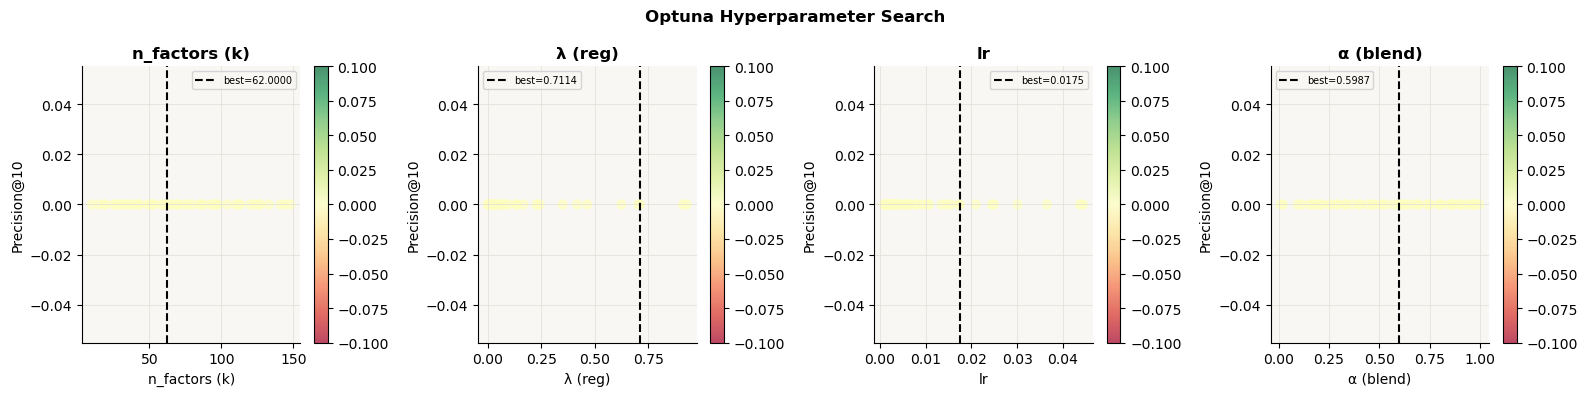

In [22]:
tdf=study.trials_dataframe()
params=['params_n_factors','params_reg_all','params_lr_all','params_alpha']
labels=['n_factors (k)','λ (reg)','lr','α (blend)']
fig,axes=plt.subplots(1,4,figsize=(16,4))
for ax,param,label in zip(axes,params,labels):
    if param not in tdf.columns: continue
    sc=ax.scatter(tdf[param],tdf['value'],c=tdf['value'],cmap='RdYlGn',alpha=0.7,s=40)
    bv=best.get(param.replace('params_',''),None)
    if bv is not None:
        ax.axvline(bv,color='black',linestyle='--',linewidth=1.5,label=f'best={bv:.4f}')
        ax.legend(fontsize=7)
    ax.set_xlabel(label); ax.set_ylabel('Precision@10')
    ax.set_title(label,fontweight='bold'); plt.colorbar(sc,ax=ax)
plt.suptitle('Optuna Hyperparameter Search',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/hyperparams.png',dpi=120,bbox_inches='tight')
plt.show()


---
## Section 14 — Experiment Logging (W&B)
**Work Package: Experiments Logging**


In [23]:
WANDB_ENABLED=False  # Set True after: pip install wandb && wandb login

if WANDB_ENABLED:
    import wandb
    for trial in study.trials:
        wandb.init(project='food-recommender-foodcom',
                    name=f'trial-{trial.number:03d}',
                    config=trial.params,reinit=True)
        wandb.log({'precision_at_10':trial.value,**trial.params})
        wandb.finish()
    print(f'{len(study.trials)} trials logged to W&B')
else:
    print('W&B disabled — set WANDB_ENABLED=True after: wandb login')
    print(f'Would log {len(study.trials)} trials')
    print(f'Best: precision@10={study.best_value:.4f}  params={best}')


W&B disabled — set WANDB_ENABLED=True after: wandb login
Would log 50 trials
Best: precision@10=0.0000  params={'n_factors': 62, 'reg_all': 0.7114476009343417, 'lr_all': 0.01752410111812814, 'alpha': 0.5986584841970366}


---
## Section 15 — Streamlit Frontend
**Work Package: Frontend Application**

Run with: `streamlit run app.py`


In [24]:
APP='''
import streamlit as st, pandas as pd, numpy as np, pickle
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px

st.set_page_config(page_title="Food Recommender",page_icon="\U0001f957",layout="wide")

FEATURE_MAX=dict(calories=2000,protein_g=150,carbs_g=300,total_fat_g=100,sodium_mg=5000,sugar_g=200)
NUM=list(FEATURE_MAX.keys())
LABEL=["diabetic_ok","low_sodium","low_calorie","high_protein","low_fat",
        "high_fiber","heart_healthy","vegetarian","vegan","gluten_free","dairy_free"]

@st.cache_data
def load(): return pd.read_csv("data/recipes_clean.csv")
df=load()
nut=df[NUM].copy()
for c,mx in FEATURE_MAX.items(): nut[c]=nut[c].fillna(0)/mx
R=pd.concat([nut,df[LABEL].fillna(0)],axis=1).values

st.title("\U0001f957 Health-Personalized Food Recommender")
st.caption(f"Food.com  |  {len(df):,} clean recipes")

c1,c2=st.columns([1,2])
with c1:
    st.subheader("Health profile")
    cal =st.slider("Target calories",200,800,450,50)
    prot=st.slider("Target protein (g)",5,80,30,5)
    carb=st.slider("Max carbs (g)",10,250,120,10)
    fat =st.slider("Max fat (g)",5,80,35,5)
    sod =st.slider("Max sodium (mg)",100,2000,600,100)
    sug =st.slider("Max sugar (g)",0,50,15,5)
    st.divider()
    diab=st.checkbox("Type 2 Diabetes  (carbs<=45g, sugar<=10g)")
    hyp =st.checkbox("Hypertension  (sodium<=600mg)")
    veg =st.checkbox("Vegan")
    gf  =st.checkbox("Gluten-free")
    k   =st.slider("Recommendations",3,20,8)

with c2:
    n=np.array([cal/2000,prot/150,carb/300,fat/100,sod/5000,sug/200])
    l=np.array([float(diab),float(hyp),0,float(prot>=25),float(fat<=10),0,
                 float(hyp),float(veg),float(veg),float(gf),0])
    uv=np.clip(np.concatenate([n,l]),0,1)
    sc=cosine_similarity(uv.reshape(1,-1),R).flatten()
    res=df.copy(); res["score"]=sc
    res=res.sort_values("score",ascending=False)
    if diab: res=res[(res["carbs_g"]<=45)&(res["sugar_g"]<=10)]
    if hyp:  res=res[res["sodium_mg"]<=600]
    if veg and "vegan" in res.columns:        res=res[res["vegan"]==1]
    if gf  and "gluten_free" in res.columns:  res=res[res["gluten_free"]==1]
    recs=res.head(k).reset_index(drop=True)
    st.subheader(f"Top {k} recommendations")
    if len(recs)==0:
        st.warning("No recipes match. Try relaxing some conditions.")
    else:
        fig=px.bar(recs,x="score",y="name",orientation="h",
                    color="score",color_continuous_scale="Teal",
                    hover_data=["calories","protein_g","carbs_g","sodium_mg"],
                    labels={"score":"Match","name":"Recipe"})
        fig.update_layout(yaxis={"categoryorder":"total ascending"},
                           height=400,showlegend=False,coloraxis_showscale=False)
        st.plotly_chart(fig,use_container_width=True)
        show_cols=[c for c in ["name","calories","protein_g","carbs_g",
                                 "total_fat_g","sodium_mg","sugar_g","minutes"]
                    if c in recs.columns]
        st.dataframe(recs[show_cols].round(1),use_container_width=True,hide_index=True)
with st.sidebar:
    st.subheader("Dataset")
    st.metric("Recipes",f"{len(df):,}")
    if "diabetic_ok" in df.columns: st.metric("Diabetic-ok",f"{int(df.diabetic_ok.sum()):,}")
    if "vegan" in df.columns:       st.metric("Vegan",f"{int(df.vegan.sum()):,}")
'''
with open('app.py','w') as f: f.write(APP)
print('app.py written.  Run:  streamlit run app.py')


IsADirectoryError: [Errno 21] Is a directory: 'app.py'

---
## Section 16 — Summary


In [25]:
import glob
print('='*55)
print('FOOD RECOMMENDER — PIPELINE SUMMARY')
print('='*55)
print(f'Recipes raw:         {len(df_recipes_raw):>8,}')
print(f'Recipes clean:       {len(df):>8,}  ({len(df)/len(df_recipes_raw):.1%} kept)')
print(f'Interactions clean:  {len(df_inter):>8,}')
print(f'USDA enriched:       {df_usda["fiber_g"].notna().sum():>8,} recipes')
print(f'Recipe matrix R:     {str(R.shape):>8}')
print(f'Health labels:       {len(LABEL_COLS):>8}')
k10=eval_df[(eval_df['method']=='CF (SVD)')&(eval_df['k']==10)].iloc[0]
print(f'CF Precision@10:     {k10["precision"]:>8.4f}')
print(f'CF Recall@10:        {k10["recall"]:>8.4f}')
print(f'CF F1@10:            {k10["f1"]:>8.4f}')
print(f'LOO Hit@10:          {np.mean(hits):>8.1%}')
print(f'Best Optuna P@10:    {study.best_value:>8.4f}')
print(f'Best params:         {best}')
plots=sorted(glob.glob('plots/*.png'))
print(f'\nPlots saved ({len(plots)}):')
for p in plots: print(f'  {p}')
print('='*55)


FOOD RECOMMENDER — PIPELINE SUMMARY
Recipes raw:           21,399
Recipes clean:         12,478  (58.3% kept)
Interactions clean:   331,247
USDA enriched:          1,793 recipes
Recipe matrix R:     (12478, 17)
Health labels:             11
CF Precision@10:       0.0000
CF Recall@10:          0.0000
CF F1@10:              0.0000
LOO Hit@10:              0.0%
Best Optuna P@10:      0.0000
Best params:         {'n_factors': 62, 'reg_all': 0.7114476009343417, 'lr_all': 0.01752410111812814, 'alpha': 0.5986584841970366}

Plots saved (21):
  plots/annotation_labels.png
  plots/eda_01_before_missing.png
  plots/eda_02_before_distributions.png
  plots/eda_03_before_consistency.png
  plots/eda_04_before_interactions.png
  plots/eda_05_cleaning_log.png
  plots/eda_06_after_missing.png
  plots/eda_07_before_after_distributions.png
  plots/eda_08_boxplots_before_after.png
  plots/eda_09_after_consistency.png
  plots/eda_10_cooktime_before_after.png
  plots/eda_11_after_interactions.png
  plots/eda